In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df_raw = pd.read_csv('../data/consumer_complaints.csv')

C:\Users\arsha\AppData\Local\Temp\ipykernel_16876\3786064847.py:1: DtypeWarning: Columns (5,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('../data/consumer_complaints.csv')


In [14]:
# --- 1. Load the Real-World Dataset (Definitive Fix) ---
# We specify the exact columns AND tell pandas to treat them all as strings ('str').
# This is the most robust method and will prevent any DtypeWarning.
columns_we_need = ['complaint_id', 'product', 'consumer_complaint_narrative', 'date_received']

try:
    df_raw = pd.read_csv(
        'C:\\Users\\arsha\\Downloads\\suppor-ticket-classifier\\data\\consumer_complaints.csv',
        usecols=columns_we_need,
        dtype=str  # This is the key change
    )
except FileNotFoundError:
    print("Error: 'complaints.csv' not found. Make sure you've downloaded it to the 'data' directory.")
except ValueError as e:
    print(f"Error loading columns: {e}. Check if the column names in 'complaints.csv' are correct.")


In [16]:
df_raw.head()

,date_received,product,consumer_complaint_narrative,complaint_id
0,08/30/2013,Mortgage,NaN,511074
1,08/30/2013,Mortgage,NaN,511080
2,08/30/2013,Credit reporting,NaN,510473
3,08/30/2013,Student loan,NaN,510326
4,08/30/2013,Debt collection,NaN,511067


In [15]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555957 entries, 0 to 555956
Data columns (total 4 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   date_received                 555957 non-null  object
 1   product                       555957 non-null  object
 2   consumer_complaint_narrative  66806 non-null   object
 3   complaint_id                  555957 non-null  object
dtypes: object(4)
memory usage: 17.0+ MB


In [19]:
# --- 2. Data Cleaning and Mapping ---
# We select and rename columns to match our project's needs and drop any rows without a description.
print("Cleaning and preparing the data...")

# Rename columns to match our project's needs
column_mapping = {
    'complaint_id': 'Ticket ID',
    'product': 'Category',
    'consumer_complaint_narrative': 'Description',
    'date_received': 'Timestamp'
}
df = df_raw.rename(columns=column_mapping)

Cleaning and preparing the data...


In [18]:
# Select, rename, and drop rows with missing descriptions
df = df_raw[columns_to_keep.keys()].rename(columns=columns_to_keep)
df.dropna(subset=['Description'], inplace=True)


KeyError: "None of [Index(['Complaint ID', 'Product', 'Consumer complaint narrative',\n       'Date received'],\n      dtype='object')] are in the [columns]"

In [20]:
# Drop rows where 'Description' is missing (though dtype=str should prevent NaNs, this is safe)
df.dropna(subset=['Description'], inplace=True)

# Focus on the top 5 most frequent categories
top_5_categories = df['Category'].value_counts().nlargest(5).index
df = df[df['Category'].isin(top_5_categories)].copy()

# Convert Timestamp to datetime objects
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [21]:
# --- 3. Exploratory Data Analysis (EDA) ---
print("\n--- Exploratory Data Analysis ---")
print(f"\nDataset shape after cleaning: {df.shape}")

print("\nFirst 5 rows of the cleaned dataset:")
display(df.head())

print("\nDataset Information:")
df.info()


--- Exploratory Data Analysis ---

Dataset shape after cleaning: (58637, 4)

First 5 rows of the cleaned dataset:


,Timestamp,Category,Description,Ticket ID
190126,2015-03-19,Debt collection,XXXX has claimed I owe them {$27.00} for XXXX ...,1290516
190155,2015-03-19,Mortgage,In XX/XX/XXXX my wages that I earned at my job...,1290524
190207,2015-03-19,Mortgage,I have an open and current mortgage with Chase...,1290253
190208,2015-03-19,Mortgage,XXXX was submitted XX/XX/XXXX. At the time I s...,1292137
190237,2015-03-19,Mortgage,Experian is reporting my OPEN and CURRENT Mort...,1290254



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 58637 entries, 190126 to 553096
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Timestamp    58637 non-null  datetime64[ns]
 1   Category     58637 non-null  object        
 2   Description  58637 non-null  object        
 3   Ticket ID    58637 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 2.2+ MB


In [22]:
print("\nTicket Category Distribution:")
category_counts = df['Category'].value_counts()
print(category_counts)


Ticket Category Distribution:
Category
Debt collection            17552
Mortgage                   14919
Credit reporting           12526
Credit card                 7929
Bank account or service     5711
Name: count, dtype: int64


C:\Users\arsha\AppData\Local\Temp\ipykernel_16876\2208135627.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


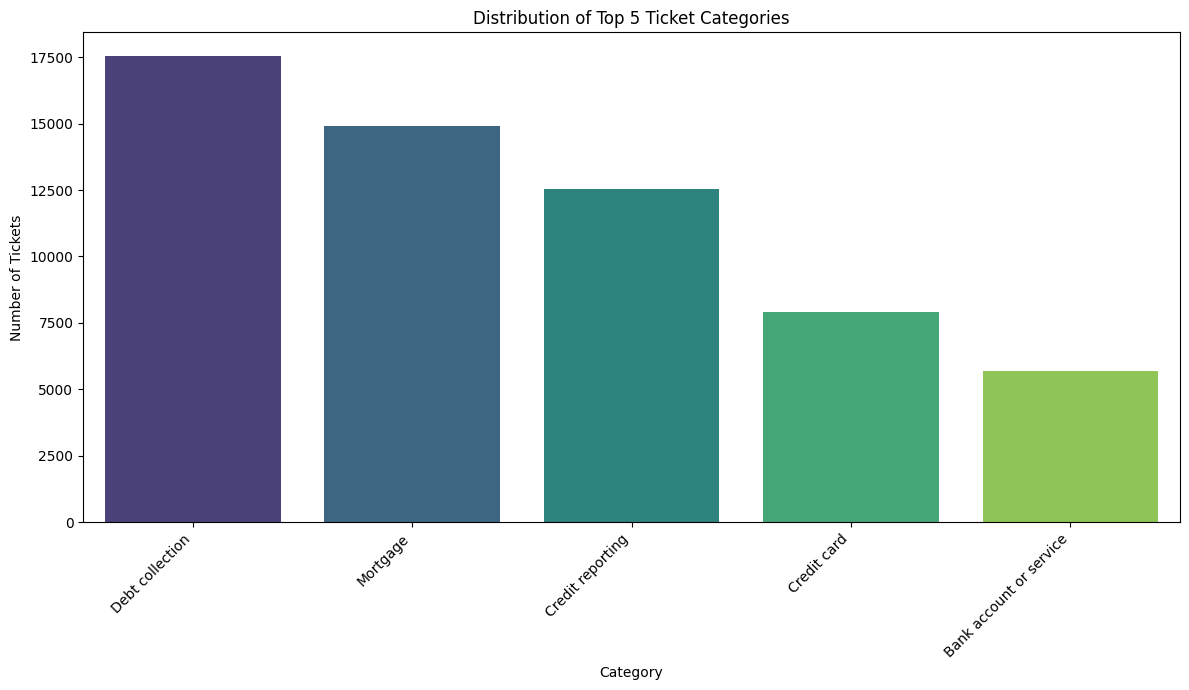

In [23]:
plt.figure(figsize=(12, 7))
sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")
plt.title('Distribution of Top 5 Ticket Categories')
plt.xlabel('Category')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [24]:
df.to_csv('complaints.csv', index=False)
